In [1]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM


# Compared analysis at the lowest resolution level

---
## Prepare data for analysis


Reload data (after clustering)

In [2]:
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]



total_time_micros = 300
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames

Time step (microseconds) 0.00019658711659778472
Time step (nanoseconds) 0.19658711659778472
Time step (picoseconds) 196.58711659778473
One microsecond in frames 5086


Fit MSM with previously chosen and validated lagtime

In [10]:
msm_lag = 100 # 20 ns
n_clusters = 100
tce = TransitionCountEstimator(lagtime=msm_lag, count_mode="sliding-effective")

msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj
cluster_centers_dict = {} # cluster centers 


for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans/{n_clusters}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(connectivity_threshold=1., directed=True)

    cluster_centers_dict[name] = submodel.transform_discrete_trajectories_to_submodel(np.arange(n_clusters))
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{n_clusters}clusters_{msm_lag}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 10000)
    if np.any(dtrajs_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

Plot eigenvalues and timescales

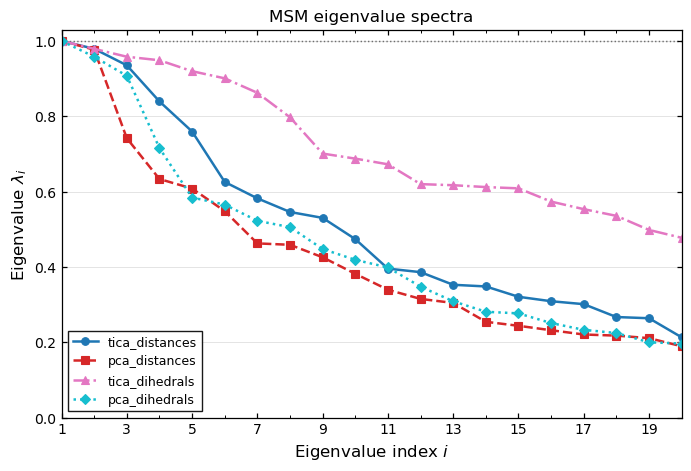

In [11]:


# ---------------------------------------------------------------------------
# Report-quality eigenvalue spectrum plot: all MSMs in one panel

os.makedirs("../output_figures", exist_ok=True)


n_eigs = 20
eig_indices = np.arange(1, n_eigs + 1)

fig, ax = plt.subplots(figsize=(6.8, 4.6), constrained_layout=True)

# Good default color cycle
colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories_labels)))
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]
    eigvals = np.asarray(msm.eigenvalues(k=n_eigs))

    ax.plot(
        eig_indices,
        eigvals,
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=1.8,
        markersize=5.5,
        markeredgewidth=0.8,
        color=colors[i],
        label=name
    )

# Reference line at lambda = 1
ax.axhline(
    1.0,
    color="black",
    linestyle=":",
    linewidth=1.0,
    alpha=0.7,
    zorder=0
)

ax.set_xlabel(r"Eigenvalue index $i$")
ax.set_ylabel(r"Eigenvalue $\lambda_i$")
ax.set_title("MSM eigenvalue spectra")

ax.set_xlim(1, n_eigs)
ax.set_ylim(0, 1.03)

ax.set_xticks(np.arange(1, n_eigs + 1, 2))
ax.set_xticks(np.arange(1, n_eigs + 1, 1), minor=True)

ax.grid(
    which="major",
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.35
)

ax.grid(
    which="minor",
    axis="y",
    linestyle=":",
    linewidth=0.5,
    alpha=0.25
)

ax.legend(
    title=None,
    frameon=True,
    fancybox=False,
    edgecolor="black",
    framealpha=0.9,
    loc="best"
)

fig.savefig(
    "../output_figures/msm_eigenvalue_spectra_report.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "../output_figures/msm_eigenvalue_spectra_report.pdf",
    bbox_inches="tight"
)

plt.show()

Comment: there is no evident separation of timescales.
this indicates a rather "flat" free energy landscape, with low barriers between basins, even between the native and denatured basin. This is consistent with the fact that the system under study is an protein that was engineered to fold extremely fast, close to physical limit. 

Markov chain lag: 19.66 ns (100 frames)


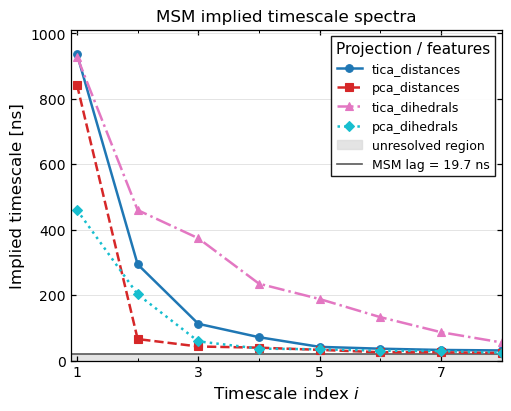

In [12]:
# ---------------------------------------------------------------------------
# Report-quality timescale spectrum plot: all MSMs in one panel

n_timescales = 8
msm_lag_ns = msm_lag * time_step_nanos
print(f"Markov chain lag: {msm_lag_ns:.2f} ns ({msm_lag} frames)")

# ---------------------------------------------------------------------------
# Figure

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories_labels)))
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]

    timescales_ns = np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos
    indices = np.arange(1, len(timescales_ns) + 1)


    ax.plot(
        indices,
        timescales_ns,
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=1.8,
        markersize=5.5,
        markeredgewidth=0.8,
        color=colors[i],
        label=rf"{name}"
    )

# ---------------------------------------------------------------------------
# MSM lag and threshold annotations

ax.axhspan(
    0,
    msm_lag_ns,
    color="0.85",
    alpha=0.7,
    zorder=0,
    label="unresolved region"
)

ax.axhline(
    msm_lag_ns,
    color="0.35",
    linestyle="-",
    linewidth=1.2,
    zorder=1,
    label=rf"MSM lag = {msm_lag_ns:.1f} ns"
)


# ---------------------------------------------------------------------------
# Axes formatting

ax.set_xlabel(r"Timescale index $i$")
ax.set_ylabel("Implied timescale [ns]")
ax.set_title("MSM implied timescale spectra")

ax.set_xlim(0.9, n_timescales)
ax.set_xticks(np.arange(1, n_timescales + 1, 2))
ax.set_xticks(np.arange(1, n_timescales + 1, 1), minor=True)

# Let the upper y-limit adapt to the data, threshold included
all_timescales = []

for name in trajectories_labels:
    msm = msm_dict[name]
    all_timescales.append(np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos)

all_timescales = np.concatenate(all_timescales)
finite_timescales = all_timescales[np.isfinite(all_timescales)]

ymax = max(
    np.nanmax(finite_timescales),
    #threshold_ns,
    msm_lag_ns
)

ax.set_ylim(0, 1.08 * ymax)

ax.grid(
    which="major",
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.35
)

ax.grid(
    which="minor",
    axis="y",
    linestyle=":",
    linewidth=0.5,
    alpha=0.25
)

ax.legend(
    title="Projection / features",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    framealpha=0.9,
    loc="best"
)
# ---------------------------------------------------------------------------
# Save figure
fig.savefig(
    "../output_figures/msm_timescale_spectra_report.png",
    dpi=600,
    bbox_inches="tight"
)
fig.savefig(
    "../output_figures/msm_timescale_spectra_report.pdf",
    bbox_inches="tight"
)
plt.show()

Compute microstate PCCA assignments (soft and hard)

In [14]:
n_common = 2

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 2
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

Project onto the timeseries (soft and hard)

In [25]:
pcca_probabilities_timeseries_dict = {}
hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]


    # probability of belonging to macrostate 1
    p_macro1 = memberships[dtraj, 1]

    # hard macrostate assignment
    hard = np.argmax(memberships[dtraj, :], axis=1)


    pcca_probabilities_timeseries_dict[name] = p_macro1
    hard_assignments_timeseries_dict[name] = hard

Outputs:

Microstates

- pcca_memberships_dict[name] #soft
- macro_assignments_micro_dict[name] # hard


Frames

- pcca_probabilities_timeseries_dict[name] 
- hard_assignments_timeseries_dict[name]

---
# Analysis start

Align models: after this step, "macrostate 0" should mean approximately the same in all models

In [27]:
reference_name = trajectories_labels[0] # tica_distances

ref_hard = hard_assignments_timeseries_dict[reference_name]

for name in trajectories_labels:
    if name == reference_name:
        continue

    hard = hard_assignments_timeseries_dict[name]

    same_agreement = np.mean(hard == ref_hard)
    flipped_agreement = np.mean((1 - hard) == ref_hard)

    if flipped_agreement > same_agreement:
        print(f"Flipping labels for {name}")

        # flip frame-wise hard labels
        hard_assignments_timeseries_dict[name] = 1 - hard_assignments_timeseries_dict[name]

        # flip frame-wise probability P(state 1)
        pcca_probabilities_timeseries_dict[name] = 1.0 - pcca_probabilities_timeseries_dict[name]

        # flip microstate membership columns
        pcca_memberships_dict[name] = pcca_memberships_dict[name][:, ::-1]

        # update microstate hard assignments
        macro_assignments_micro_dict[name] = 1 - macro_assignments_micro_dict[name]

No flipping

Pairwise hard label agreement

In [28]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import numpy as np

names = trajectories_labels
n = len(names)

agreement_fraction = np.zeros((n, n))
ari_matrix = np.zeros((n, n))
nmi_matrix = np.zeros((n, n))

for i, name_i in enumerate(names):
    for j, name_j in enumerate(names):
        hi = hard_assignments_timeseries_dict[name_i]
        hj = hard_assignments_timeseries_dict[name_j]

        agreement_fraction[i, j] = np.mean(hi == hj)
        ari_matrix[i, j] = adjusted_rand_score(hi, hj)
        nmi_matrix[i, j] = normalized_mutual_info_score(hi, hj)

In [30]:
for i, name_i in enumerate(names):
    for j, name_j in enumerate(names):
        if i < j:
            print("\n")
            print(f"{name_i} vs {name_j}:")
            print(f"  Agreement fraction: {agreement_fraction[i, j]:.4f}")
            print(f"  Adjusted Rand Index: {ari_matrix[i, j]:.4f}")
            print(f"  Normalized Mutual Information: {nmi_matrix[i, j]:.4f}")



tica_distances vs pca_distances:
  Agreement fraction: 0.9895
  Adjusted Rand Index: 0.9576
  Normalized Mutual Information: 0.9126


tica_distances vs tica_dihedrals:
  Agreement fraction: 0.8047
  Adjusted Rand Index: 0.3184
  Normalized Mutual Information: 0.2987


tica_distances vs pca_dihedrals:
  Agreement fraction: 0.9640
  Adjusted Rand Index: 0.8591
  Normalized Mutual Information: 0.7636


pca_distances vs tica_dihedrals:
  Agreement fraction: 0.7988
  Adjusted Rand Index: 0.3076
  Normalized Mutual Information: 0.2985


pca_distances vs pca_dihedrals:
  Agreement fraction: 0.9656
  Adjusted Rand Index: 0.8653
  Normalized Mutual Information: 0.7685


tica_dihedrals vs pca_dihedrals:
  Agreement fraction: 0.7908
  Adjusted Rand Index: 0.2926
  Normalized Mutual Information: 0.2930


Pairwise comparison of the two-state PCCA hard assignments shows strong agreement between the two distance-based models and the PCA-dihedral model, with ARI values between 0.86 and 0.96 and NMI values between 0.76 and 0.91. In contrast, the tICA-dihedral model shows substantially weaker agreement with the distance-based models, with ARI values around 0.31 and NMI values around 0.30. Thus, at the lowest common resolution, the dominant partition is robust across three of the four representations, while the tICA-dihedral model appears to define a different or less sharply resolved decomposition.


The tICA-dihedral model resolves a more fragmented slow landscape and lacks a pronounced eigenvalue gap at the two-state level; consequently, its forced two-state PCCA partition is less directly comparable to the coarser models.

Compare fuzzy membership probabilities

In [31]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
import pandas as pd

names = trajectories_labels
n = len(names)

pearson_matrix = np.zeros((n, n))
spearman_matrix = np.zeros((n, n))

for i, name_i in enumerate(names):
    for j, name_j in enumerate(names):
        pi = pcca_probabilities_timeseries_dict[name_i]
        pj = pcca_probabilities_timeseries_dict[name_j]

        pearson_matrix[i, j] = pearsonr(pi, pj)[0]
        spearman_matrix[i, j] = spearmanr(pi, pj)[0]

pearson_df = pd.DataFrame(
    pearson_matrix,
    index=names,
    columns=names
)

spearman_df = pd.DataFrame(
    spearman_matrix,
    index=names,
    columns=names
)

pearson_df, spearman_df

(                tica_distances  pca_distances  tica_dihedrals  pca_dihedrals
 tica_distances        1.000000       0.989579        0.923181       0.875775
 pca_distances         0.989579       1.000000        0.909908       0.875568
 tica_dihedrals        0.923181       0.909908        1.000000       0.885468
 pca_dihedrals         0.875775       0.875568        0.885468       1.000000,
                 tica_distances  pca_distances  tica_dihedrals  pca_dihedrals
 tica_distances        1.000000       0.910527        0.825732       0.830792
 pca_distances         0.910527       1.000000        0.820823       0.846514
 tica_dihedrals        0.825732       0.820823        1.000000       0.930410
 pca_dihedrals         0.830792       0.846514        0.930410       1.000000)

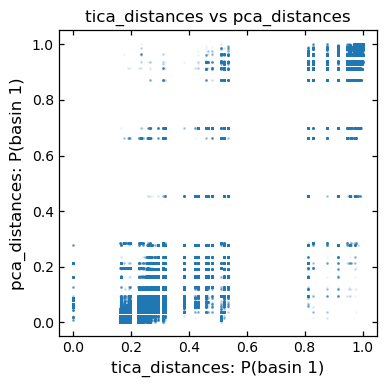

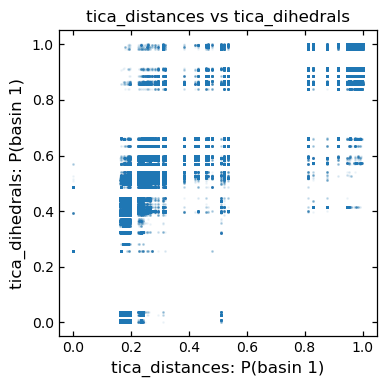

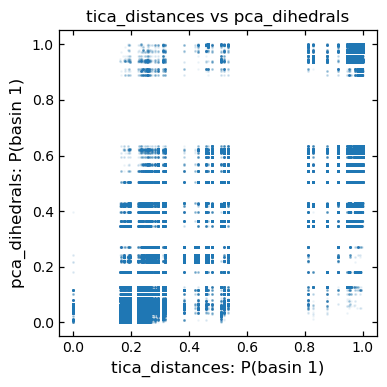

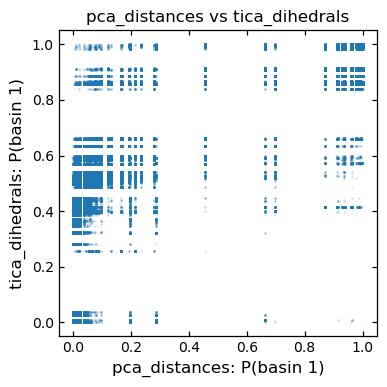

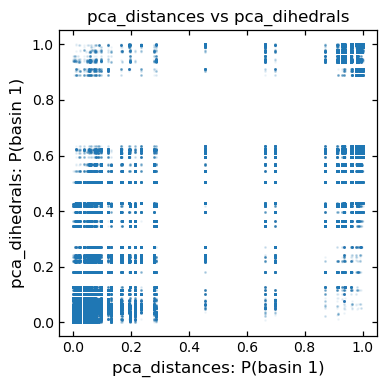

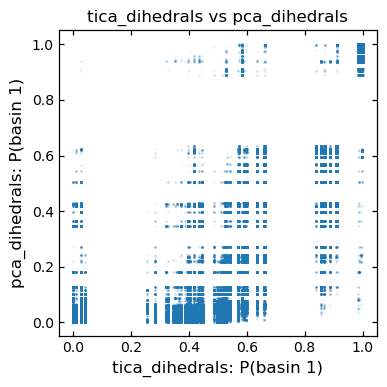

In [32]:
for i, name_i in enumerate(names):
    for j, name_j in enumerate(names):
        if i < j:
            pi = pcca_probabilities_timeseries_dict[name_i]
            pj = pcca_probabilities_timeseries_dict[name_j]

            fig, ax = plt.subplots(figsize=(4, 4))
            ax.scatter(pi, pj, s=1, alpha=0.05)

            ax.set_xlabel(f"{name_i}: P(basin 1)")
            ax.set_ylabel(f"{name_j}: P(basin 1)")
            ax.set_title(f"{name_i} vs {name_j}")

            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.05, 1.05)

            plt.tight_layout()

Fuzzy equilibrium populations

In [33]:
state_populations_fuzzy = {}

for name in names:
    msm = msm_dict[name]
    pi = msm.stationary_distribution
    memberships = pcca_memberships_dict[name]

    pops = pi @ memberships
    state_populations_fuzzy[name] = pops



population_df = pd.DataFrame(
    {
        name: state_populations_fuzzy[name]
        for name in names
    },
    index=["basin_0", "basin_1"]
).T

population_df

,basin_0,basin_1
tica_distances,0.246682,0.753318
pca_distances,0.307173,0.692827
tica_dihedrals,0.204607,0.795393
pca_dihedrals,0.438949,0.561051


Relative free energy differences

In [34]:
kBT = 2.494 * 370/300  # kJ/mol at 300 K

deltaG_dict = {}

for name in names:
    p0, p1 = state_populations_fuzzy[name]
    deltaG_dict[name] = -kBT * np.log(p1 / p0)

deltaG_df = pd.DataFrame.from_dict(
    deltaG_dict,
    orient="index",
    columns=["DeltaG_1_minus_0_kJmol"]
)

deltaG_df

,DeltaG_1_minus_0_kJmol
tica_distances,-3.433925
pca_distances,-2.501865
tica_dihedrals,-4.176336
pca_dihedrals,-0.754917


Define core and ambiguous frame masks

In [35]:
region_masks_dict = {}

for name in names:
    p = pcca_probabilities_timeseries_dict[name]

    region_masks_dict[name] = {
        "state0_core": p < 0.2,
        "state1_core": p > 0.8,
        "ambiguous": (p > 0.4) & (p < 0.6),
    }

Core-overlap matrices

In [36]:
def jaccard(mask_a, mask_b):
    union = np.sum(mask_a | mask_b)
    if union == 0:
        return np.nan
    return np.sum(mask_a & mask_b) / union


core_overlap_state0 = np.zeros((n, n))
core_overlap_state1 = np.zeros((n, n))
ambiguous_overlap = np.zeros((n, n))

for i, name_i in enumerate(names):
    for j, name_j in enumerate(names):
        masks_i = region_masks_dict[name_i]
        masks_j = region_masks_dict[name_j]

        core_overlap_state0[i, j] = jaccard(
            masks_i["state0_core"],
            masks_j["state0_core"]
        )

        core_overlap_state1[i, j] = jaccard(
            masks_i["state1_core"],
            masks_j["state1_core"]
        )

        ambiguous_overlap[i, j] = jaccard(
            masks_i["ambiguous"],
            masks_j["ambiguous"]
        )

In [37]:
for i, name_i in enumerate(names):
    for j, name_j in enumerate(names):
        if i < j:
            print("\n")
            print(f"{name_i} vs {name_j}:")
            print(f"  Core overlap state 0: {core_overlap_state0[i, j]:.4f}")
            print(f"  Core overlap state 1: {core_overlap_state1[i, j]:.4f}")
            print(f"  Ambiguous overlap: {ambiguous_overlap[i, j]:.4f}")



tica_distances vs pca_distances:
  Core overlap state 0: 0.3642
  Core overlap state 1: 0.9894
  Ambiguous overlap: 0.1602


tica_distances vs tica_dihedrals:
  Core overlap state 0: 0.2552
  Core overlap state 1: 0.9814
  Ambiguous overlap: 0.0811


tica_distances vs pca_dihedrals:
  Core overlap state 0: 0.3958
  Core overlap state 1: 0.4581
  Ambiguous overlap: 0.0437


pca_distances vs tica_dihedrals:
  Core overlap state 0: 0.1026
  Core overlap state 1: 0.9772
  Ambiguous overlap: 0.0067


pca_distances vs pca_dihedrals:
  Core overlap state 0: 0.8509
  Core overlap state 1: 0.4594
  Ambiguous overlap: 0.0090


tica_dihedrals vs pca_dihedrals:
  Core overlap state 0: 0.1125
  Core overlap state 1: 0.4570
  Ambiguous overlap: 0.0179


pca dihedrals is telling a different story alltogether


the other three methods agree well on state 1, poorly on state 0, and do not agree at all on transition frames.

The folded basin is the only robust object across models. The unfolded/non-folded basin and the ambiguous boundary regions are much more model-dependent.


The non-folded basin is more heterogeneous and model-dependent.

The low overlap of ambiguous regions indicates that the location and extent of the transition-like boundary are representation-dependent.



Core-set overlaps show that the folded basin is the most robust feature of the two-state decompositions. The folded core, corresponding to basin 1, is almost identical between tica_distances, pca_distances, and tica_dihedrals, with Jaccard overlaps of approximately 0.98–0.99. In contrast, overlaps for basin 0 are substantially lower, indicating that the non-folded ensemble is more heterogeneous and representation-dependent. The ambiguous regions show very low overlap across models, suggesting that the precise boundary between basins is not robust to the choice of features and dimensional reduction. Therefore, subsequent structural interpretation should focus primarily on the robust folded core, while treating the non-folded basin and transition-like frames with more caution.

---
# Structural analysis of the folded basin (robust across the three models)


Do not overcomplicate this. For the robust folded basin, you want to show:

The consensus folded core corresponds to compact, native-like three-helix structures with stable secondary structure and native tertiary packing.

In [39]:
folded_core_consensus = (
    region_masks_dict["tica_distances"]["state1_core"] &
    region_masks_dict["pca_distances"]["state1_core"] &
    region_masks_dict["tica_dihedrals"]["state1_core"]
)

Load descriptor timeseries

In [67]:
contacts_timeseries = np.loadtxt(data_folder + "hp35.crystaldists", delimiter = " ", dtype = float)
contacts_index = np.loadtxt(data_folder + "hp35.crystaldists.ndx", delimiter = " ", dtype = int)

dihedrals_timeseries = np.loadtxt(data_folder + "hp35.dihs", delimiter = " ", dtype = float)
dihedrals_index = np.loadtxt(data_folder + "hp35.dihs.names", delimiter = " ", dtype = str)

1. Aromatic residues in the hydrophobic core

In [77]:
core_aromatic_residues = [6, 10, 17]
core_contact_labels = [(i, j) for i in core_aromatic_residues for j in core_aromatic_residues if i < j]
core_dihedrals = [f"phi_{i}" for i in core_aromatic_residues] + [f"psi_{i}" for i in core_aromatic_residues]

In [78]:
core_contacts_idxs = [
                        np.where((contacts_index[:, 0] == pair[0]) & (contacts_index[:, 1] == pair[1]))[0]
                        for pair in core_contact_labels
                    ]
core_contact_timeseries = contacts_timeseries[:, np.concatenate(core_contacts_idxs)]
core_dihedrals_idxs = [
                        np.where(np.isin(dihedrals_index, dihedral))[0]
                        for dihedral in core_dihedrals
]
core_dihedral_timeseries = dihedrals_timeseries[:, np.concatenate(core_dihedrals_idxs)]

In [79]:
folded_mask = folded_core_consensus
other_mask = ~folded_core_consensus

print("Folded frames:", folded_mask.sum())
print("Other frames:", other_mask.sum())
print("Folded fraction:", folded_mask.mean())

Folded frames: 1019258
Other frames: 506783
Folded fraction: 0.6679099709640829


In [80]:
def summarize_contact_array(x, cutoff):
    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "formed_fraction": np.mean(x < cutoff),
    }

In [84]:
contact_cutoff = 0.8  # nm
contact_rows = []

for k, pair in enumerate(core_contact_labels):
    x = core_contact_timeseries[:, k]

    folded_stats = summarize_contact_array(x[folded_mask], contact_cutoff)
    other_stats = summarize_contact_array(x[other_mask], contact_cutoff)

    row = {
        "contact": tuple(pair),
        "res_i": pair[0],
        "res_j": pair[1],

        "mean_folded": folded_stats["mean"],
        "std_folded": folded_stats["std"],
        "median_folded": folded_stats["median"],
        "q25_folded": folded_stats["q25"],
        "q75_folded": folded_stats["q75"],
        "iqr_folded": folded_stats["iqr"],
        "formed_fraction_folded": folded_stats["formed_fraction"],

        "mean_other": other_stats["mean"],
        "std_other": other_stats["std"],
        "median_other": other_stats["median"],
        "iqr_other": other_stats["iqr"],
        "formed_fraction_other": other_stats["formed_fraction"],
    }

    row["delta_mean_other_minus_folded"] = row["mean_other"] - row["mean_folded"]
    row["delta_formed_folded_minus_other"] = (
        row["formed_fraction_folded"] - row["formed_fraction_other"]
    )

    contact_rows.append(row)

core_contact_df = pd.DataFrame(contact_rows)

core_contact_df = core_contact_df.sort_values(
    "delta_formed_folded_minus_other",
    ascending=False
)

core_contact_df

,contact,res_i,res_j,mean_folded,std_folded,median_folded,q25_folded,q75_folded,iqr_folded,formed_fraction_folded,mean_other,std_other,median_other,iqr_other,formed_fraction_other,delta_mean_other_minus_folded,delta_formed_folded_minus_other
1,"(6, 17)",6,17,0.440813,0.075682,0.42189,0.38450,0.48552,0.10102,0.997035,1.393627,0.550960,1.38059,0.76301,0.163232,0.952814,0.833803
2,"(10, 17)",10,17,0.530411,0.118158,0.52681,0.43476,0.61114,0.17638,0.984353,1.244959,0.474249,1.24763,0.69660,0.208440,0.714549,0.775913
0,"(6, 10)",6,10,0.312306,0.047195,0.29665,0.28557,0.31412,0.02855,0.999997,0.652274,0.263910,0.67703,0.50307,0.656745,0.339968,0.343252


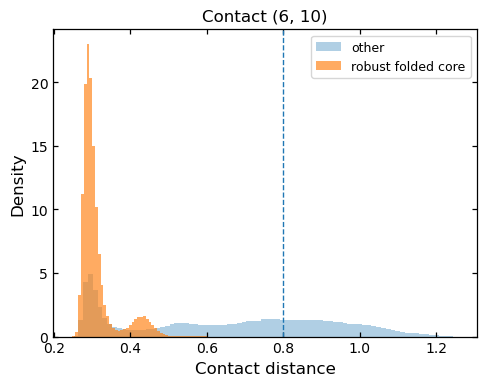

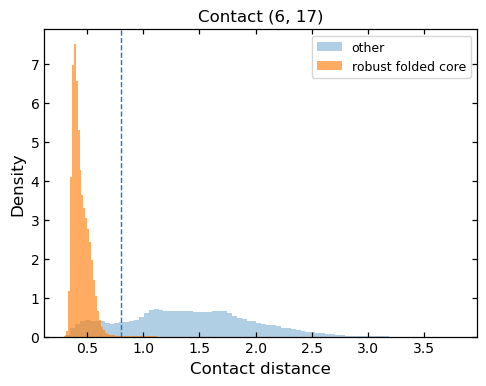

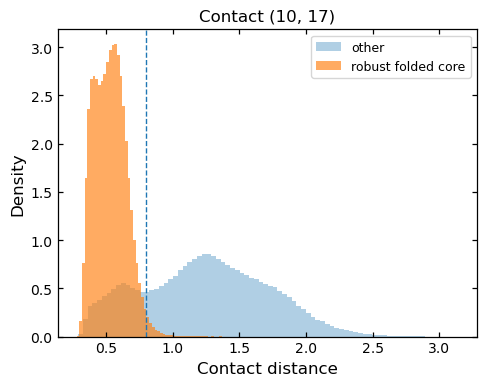

In [85]:
for k, pair in enumerate(core_contact_labels):
    x = core_contact_timeseries[:, k]

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.hist(
        x[other_mask],
        bins=80,
        density=True,
        alpha=0.35,
        label="other"
    )

    ax.hist(
        x[folded_mask],
        bins=80,
        density=True,
        alpha=0.65,
        label="robust folded core"
    )

    ax.axvline(contact_cutoff, linestyle="--", linewidth=1.0)

    ax.set_xlabel("Contact distance")
    ax.set_ylabel("Density")
    ax.set_title(f"Contact {tuple(pair)}")
    ax.legend()

    plt.tight_layout()

2. All contacts

In [89]:
contact_cutoff = 0.8  # nm
contact_rows = []

for k, pair in enumerate(contacts_index):
    x = contacts_timeseries[:, k]

    folded_stats = summarize_contact_array(x[folded_mask], contact_cutoff)
    other_stats = summarize_contact_array(x[other_mask], contact_cutoff)

    row = {
        "contact": tuple(pair),
        "res_i": pair[0],
        "res_j": pair[1],

        "mean_folded": folded_stats["mean"],
        "std_folded": folded_stats["std"],
        "median_folded": folded_stats["median"],
        "q25_folded": folded_stats["q25"],
        "q75_folded": folded_stats["q75"],
        "iqr_folded": folded_stats["iqr"],
        "formed_fraction_folded": folded_stats["formed_fraction"],

        "mean_other": other_stats["mean"],
        "std_other": other_stats["std"],
        "median_other": other_stats["median"],
        "iqr_other": other_stats["iqr"],
        "formed_fraction_other": other_stats["formed_fraction"],
    }

    row["delta_mean_other_minus_folded"] = row["mean_other"] - row["mean_folded"]
    row["delta_formed_folded_minus_other"] = (
        row["formed_fraction_folded"] - row["formed_fraction_other"]
    )

    contact_rows.append(row)

all_contact_df = pd.DataFrame(contact_rows)

all_contact_df = all_contact_df.sort_values(
    "delta_formed_folded_minus_other",
    ascending=False
)

In [90]:
eps = 1e-12

all_contact_df["pooled_std"] = np.sqrt(
    0.5 * (
        all_contact_df["std_folded"]**2 +
        all_contact_df["std_other"]**2
    )
)

all_contact_df["distance_effect_size"] = (
    all_contact_df["mean_other"] - all_contact_df["mean_folded"]
) / (all_contact_df["pooled_std"] + eps)

all_contact_df["formed_odds_ratio"] = (
    (all_contact_df["formed_fraction_folded"] + eps)
    / (1 - all_contact_df["formed_fraction_folded"] + eps)
) / (
    (all_contact_df["formed_fraction_other"] + eps)
    / (1 - all_contact_df["formed_fraction_other"] + eps)
)

all_contact_df["log2_formed_odds_ratio"] = np.log2(
    all_contact_df["formed_odds_ratio"] + eps
)

distance_effect_size > 0:
    contact is shorter in folded basin than outside

large distance_effect_size:
    folded and other distance distributions are well separated

log2_formed_odds_ratio > 0:
    contact is more likely formed in folded basin than outside

In [91]:
all_contact_df["folded_contact_score"] = (
    all_contact_df["delta_formed_folded_minus_other"]
    + 0.25 * all_contact_df["distance_effect_size"]
    - 0.5 * all_contact_df["iqr_folded"]
)

In [93]:
ranked_contacts = all_contact_df.sort_values(
    "folded_contact_score",
    ascending=False
)

ranked_contacts[
    [
        "contact",
        "res_i",
        "res_j",
        "mean_folded",
        "mean_other",
        "formed_fraction_folded",
        "formed_fraction_other",
        "delta_formed_folded_minus_other",
        "distance_effect_size",
        "iqr_folded",
        "folded_contact_score",
    ]
].head(30)

most_different_contacts = all_contact_df[
    (all_contact_df["formed_fraction_folded"] > 0.7) &
    (all_contact_df["formed_fraction_other"] < 0.4) &
    (all_contact_df["delta_formed_folded_minus_other"] > 0.4) &
    (all_contact_df["distance_effect_size"] > 1.0)
].sort_values(
    "folded_contact_score",
    ascending=False
)

most_different_contacts

,contact,res_i,res_j,mean_folded,std_folded,median_folded,q25_folded,q75_folded,iqr_folded,formed_fraction_folded,...,median_other,iqr_other,formed_fraction_other,delta_mean_other_minus_folded,delta_formed_folded_minus_other,pooled_std,distance_effect_size,formed_odds_ratio,log2_formed_odds_ratio,folded_contact_score
16,"(6, 17)",6,17,0.440813,0.075682,0.42189,0.38450,0.485520,0.101020,0.997035,...,1.38059,0.763010,0.163232,0.952814,0.833803,0.393246,2.422946,1723.856650,10.751424,1.389030
15,"(6, 14)",6,14,0.489747,0.081306,0.48799,0.42447,0.544850,0.120380,0.997834,...,1.21064,0.573275,0.156605,0.743282,0.841228,0.309021,2.405281,2480.658734,11.276508,1.382359
18,"(7, 12)",7,12,0.376494,0.043202,0.36965,0.34828,0.395610,0.047330,0.999983,...,1.03553,0.483200,0.288042,0.630126,0.711941,0.238055,2.646971,148192.291057,17.177111,1.350019
19,"(7, 13)",7,13,0.509909,0.088560,0.48744,0.45143,0.540900,0.089470,0.987996,...,1.15806,0.523050,0.202071,0.627216,0.785925,0.258711,2.424392,325.009802,8.344339,1.347288
13,"(6, 12)",6,12,0.487512,0.107731,0.53320,0.36638,0.575640,0.209260,0.998503,...,1.15337,0.525365,0.168038,0.686088,0.830464,0.282679,2.427091,3301.974137,11.689113,1.332607
20,"(9, 32)",9,32,0.472264,0.323086,0.35887,0.32417,0.454857,0.130687,0.915644,...,1.63476,0.932780,0.103900,1.149743,0.811743,0.494378,2.325635,93.615279,6.548672,1.327808
14,"(6, 13)",6,13,0.566556,0.120155,0.59029,0.45582,0.658040,0.202220,0.988680,...,1.24098,0.562195,0.143651,0.690694,0.845029,0.308316,2.240212,520.655765,9.024186,1.303972
24,"(10, 29)",10,29,0.545992,0.115974,0.52879,0.45352,0.617850,0.164330,0.970828,...,1.43062,0.848795,0.159652,0.888118,0.811176,0.419116,2.119028,175.169015,7.452604,1.258768
23,"(10, 28)",10,28,0.512803,0.137974,0.50107,0.39184,0.603160,0.211320,0.970805,...,1.43103,0.886300,0.166797,0.924891,0.804008,0.433882,2.131663,166.107395,7.375972,1.231264
25,"(10, 32)",10,32,0.583719,0.234167,0.52938,0.43334,0.641960,0.208620,0.897906,...,1.60215,0.966835,0.121681,1.022946,0.776225,0.477469,2.142437,63.483322,5.988306,1.207524


In [94]:
n_res = int(max(contacts_index.max(), 35)) + 1

contact_map_delta = np.full((n_res, n_res), np.nan)

for _, row in all_contact_df.iterrows():
    i = int(row["res_i"])
    j = int(row["res_j"])
    value = row["delta_formed_folded_minus_other"]

    contact_map_delta[i, j] = value
    contact_map_delta[j, i] = value

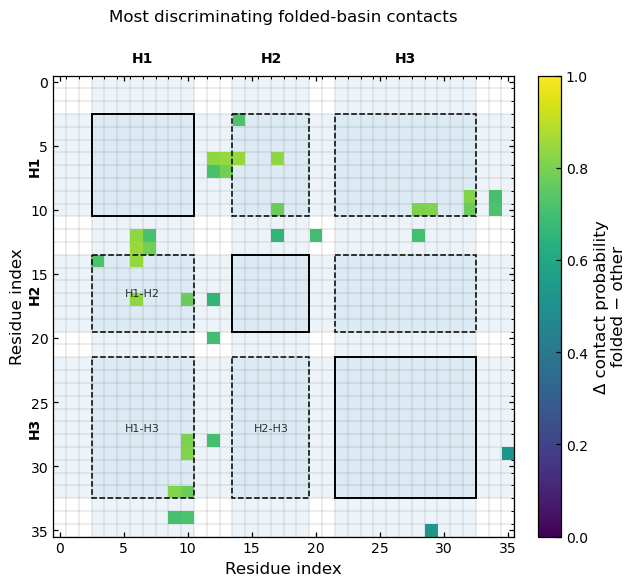

In [102]:

from matplotlib.patches import Rectangle

# Build filtered contact map
contact_map_filtered = np.full((n_res, n_res), np.nan)

for _, row in most_different_contacts.iterrows():
    i = int(row["res_i"])
    j = int(row["res_j"])
    value = row["delta_formed_folded_minus_other"]

    contact_map_filtered[i, j] = value
    contact_map_filtered[j, i] = value


helix_ranges = {
    "H1": (3, 10),
    "H2": (14, 19),
    "H3": (22, 32),
}

fig, ax = plt.subplots(figsize=(7, 6))

# --- light background shading for helix rows/columns ---
for hname, (start, end) in helix_ranges.items():
    # vertical helix band
    ax.axvspan(
        start - 0.5,
        end + 0.5,
        alpha=0.08,
        zorder=0
    )

    # horizontal helix band
    ax.axhspan(
        start - 0.5,
        end + 0.5,
        alpha=0.08,
        zorder=0
    )

# --- main contact map ---
im = ax.imshow(
    contact_map_filtered,
    origin="lower",
    vmin=0,
    vmax=1,
    zorder=2
)

# --- grid ---
ax.set_xticks(np.arange(-0.5, n_res, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_res, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.35, alpha=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# --- helix boundaries and labels ---
for hname, (start, end) in helix_ranges.items():
    width = end - start + 1

    # square block around same-helix region
    rect = Rectangle(
        (start - 0.5, start - 0.5),
        width,
        width,
        fill=False,
        linestyle="-",
        linewidth=1.4,
        zorder=4
    )
    ax.add_patch(rect)

    # axis labels for helices
    center = (start + end) / 2

    ax.text(
        center,
        -1.9,
        hname,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        clip_on=False
    )

    ax.text(
        -1.9,
        center,
        hname,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        rotation=90,
        clip_on=False
    )

# --- boxes around inter-helix regions ---
helix_items = list(helix_ranges.items())

for idx_a, (h1, (s1, e1)) in enumerate(helix_items):
    for idx_b, (h2, (s2, e2)) in enumerate(helix_items):
        if idx_b <= idx_a:
            continue

        w1 = e1 - s1 + 1
        w2 = e2 - s2 + 1

        # upper/lower symmetric inter-helix blocks
        rect1 = Rectangle(
            (s1 - 0.5, s2 - 0.5),
            w1,
            w2,
            fill=False,
            linestyle="--",
            linewidth=1.1,
            zorder=4
        )
        rect2 = Rectangle(
            (s2 - 0.5, s1 - 0.5),
            w2,
            w1,
            fill=False,
            linestyle="--",
            linewidth=1.1,
            zorder=4
        )

        ax.add_patch(rect1)
        ax.add_patch(rect2)

        # optional inter-helix label in one triangle only
        ax.text(
            (s1 + e1) / 2,
            (s2 + e2) / 2,
            f"{h1}-{h2}",
            ha="center",
            va="center",
            fontsize=8,
            alpha=0.8,
            zorder=5
        )

# --- axes ---
ax.set_xlim(-0.5, n_res - 0.5)
ax.set_ylim(n_res - 0.5, -0.5)  # keeps residue 0 at top, like your current plot
ax.set_aspect("equal")

ax.set_xlabel("Residue index")
ax.set_ylabel("Residue index")
ax.set_title("Most discriminating folded-basin contacts", y = 1.1)

# Cleaner tick spacing
major_ticks = np.arange(0, n_res, 5)
ax.set_xticks(major_ticks)
ax.set_yticks(major_ticks)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Δ contact probability\nfolded − other")

plt.tight_layout()

### Dihedrals

In [104]:
print("dihedrals_timeseries shape:", dihedrals_timeseries.shape)
print("dihedrals_index shape:", dihedrals_index.shape)
print("first entries:")
print(dihedrals_index[:10])
print("min/max angles:", np.nanmin(dihedrals_timeseries), np.nanmax(dihedrals_timeseries))


dihedrals_rad = np.deg2rad(dihedrals_timeseries)

dihedrals_timeseries shape: (1526041, 66)
dihedrals_index shape: (66,)
first entries:
['phi2' 'psi2' 'phi3' 'psi3' 'phi4' 'psi4' 'phi5' 'psi5' 'phi6' 'psi6']
min/max angles: -180.0 180.0


In [105]:
def circular_mean(theta):
    return np.arctan2(
        np.mean(np.sin(theta)),
        np.mean(np.cos(theta))
    )

def circular_resultant_length(theta):
    """
    R close to 1: tightly localized angle.
    R close to 0: broad or multimodal angle.
    """
    return np.sqrt(
        np.mean(np.cos(theta))**2 +
        np.mean(np.sin(theta))**2
    )

def circular_variance(theta):
    return 1.0 - circular_resultant_length(theta)

def circular_std(theta):
    R = circular_resultant_length(theta)
    R = np.clip(R, 1e-12, 1.0)
    return np.sqrt(-2.0 * np.log(R))

def angular_difference(theta, theta0):
    """
    Signed difference between two angles, wrapped to [-pi, pi].
    """
    return np.arctan2(
        np.sin(theta - theta0),
        np.cos(theta - theta0)
    )

def circular_mean_abs_difference(theta_a, theta_b):
    """
    Mean absolute angular difference between two samples or one sample and one angle.
    """
    d = angular_difference(theta_a, theta_b)
    return np.mean(np.abs(d))

In [106]:
dihedral_rows = []

for k in range(dihedrals_rad.shape[1]):
    x = dihedrals_rad[:, k]

    x_folded = x[folded_mask]
    x_other = x[other_mask]

    mean_folded = circular_mean(x_folded)
    mean_other = circular_mean(x_other)

    R_folded = circular_resultant_length(x_folded)
    R_other = circular_resultant_length(x_other)

    circ_std_folded = circular_std(x_folded)
    circ_std_other = circular_std(x_other)

    mean_shift = np.abs(angular_difference(mean_folded, mean_other))

    row = {
        "dihedral_col": k,
        "dihedral_label": tuple(np.atleast_1d(dihedrals_index[k])),

        "circ_mean_folded_rad": mean_folded,
        "circ_mean_other_rad": mean_other,
        "circ_mean_folded_deg": np.rad2deg(mean_folded),
        "circ_mean_other_deg": np.rad2deg(mean_other),

        "R_folded": R_folded,
        "R_other": R_other,
        "delta_R_folded_minus_other": R_folded - R_other,

        "circ_std_folded_rad": circ_std_folded,
        "circ_std_other_rad": circ_std_other,
        "circ_std_folded_deg": np.rad2deg(circ_std_folded),
        "circ_std_other_deg": np.rad2deg(circ_std_other),

        "mean_shift_rad": mean_shift,
        "mean_shift_deg": np.rad2deg(mean_shift),
    }

    dihedral_rows.append(row)

all_dihedral_df = pd.DataFrame(dihedral_rows)

For the folded/native basin, a useful dihedral is one that is:

1. ordered in the folded basin,
2. more ordered than outside,
3. has a different mean angle from outside, if relevant.

In [107]:
all_dihedral_df["folded_dihedral_score"] = (
    all_dihedral_df["R_folded"]
    + all_dihedral_df["delta_R_folded_minus_other"]
    + 0.25 * (all_dihedral_df["mean_shift_rad"] / np.pi)
)

In [109]:
ranked_dihedrals = all_dihedral_df.sort_values(
    "folded_dihedral_score",
    ascending=False
)

ranked_dihedrals[
    [
        "dihedral_col",
        "dihedral_label",
        "circ_mean_folded_deg",
        "circ_mean_other_deg",
        "R_folded",
        "R_other",
        "delta_R_folded_minus_other",
        "circ_std_folded_deg",
        "circ_std_other_deg",
        "mean_shift_deg",
        "folded_dihedral_score",
    ]
]

most_different_dihedrals = all_dihedral_df[
    (all_dihedral_df["R_folded"] > 0.75) &
    (all_dihedral_df["delta_R_folded_minus_other"] > 0.20) &
    (all_dihedral_df["mean_shift_deg"] > 20)
].sort_values(
    "folded_dihedral_score",
    ascending=False
)

most_different_dihedrals

,dihedral_col,dihedral_label,circ_mean_folded_rad,circ_mean_other_rad,circ_mean_folded_deg,circ_mean_other_deg,R_folded,R_other,delta_R_folded_minus_other,circ_std_folded_rad,circ_std_other_rad,circ_std_folded_deg,circ_std_other_deg,mean_shift_rad,mean_shift_deg,folded_dihedral_score
23,23,"(psi13,)",2.802340,-0.025572,160.562232,-1.465140,0.987093,0.247621,0.739471,0.161192,1.670841,9.235618,95.732140,2.827911,162.027373,1.951602
21,21,"(psi12,)",2.838442,0.068616,162.630727,3.931423,0.977915,0.249578,0.728337,0.211341,1.666124,12.108928,95.461869,2.769825,158.699304,1.926668
18,18,"(phi11,)",1.301782,0.662530,74.586601,37.960162,0.916902,0.124825,0.792078,0.416543,2.040022,23.866183,116.884627,0.639252,36.626439,1.759850
19,19,"(psi11,)",0.065657,-0.451989,3.761855,-25.897052,0.934060,0.193138,0.740922,0.369363,1.813477,21.162939,103.904606,0.517646,29.658907,1.716175
13,13,"(psi8,)",-0.416694,-0.049867,-23.874797,-2.857191,0.949009,0.307099,0.641910,0.323532,1.536609,18.537034,88.041232,0.366826,21.017606,1.620111
27,27,"(psi15,)",-0.605142,-0.145605,-34.672095,-8.342580,0.975596,0.393388,0.582208,0.222290,1.365986,12.736299,78.265247,0.459537,26.329515,1.594373
17,17,"(psi10,)",-0.125467,0.316491,-7.188754,18.133584,0.917989,0.277533,0.640456,0.413691,1.601134,23.702767,91.738237,0.441958,25.322339,1.593614
15,15,"(psi9,)",-0.655299,-0.036026,-37.545842,-2.064121,0.964667,0.388757,0.575910,0.268226,1.374629,15.368218,78.760415,0.619273,35.481722,1.589857
29,29,"(psi16,)",-0.633146,-0.180236,-36.276605,-10.326782,0.982563,0.475469,0.507094,0.187565,1.219387,10.746695,69.865741,0.452910,25.949823,1.525699
63,63,"(psi33,)",0.467948,2.169746,26.811451,124.317304,0.762538,0.158688,0.603850,0.736347,1.918758,42.189584,109.936714,1.701798,97.505853,1.501812


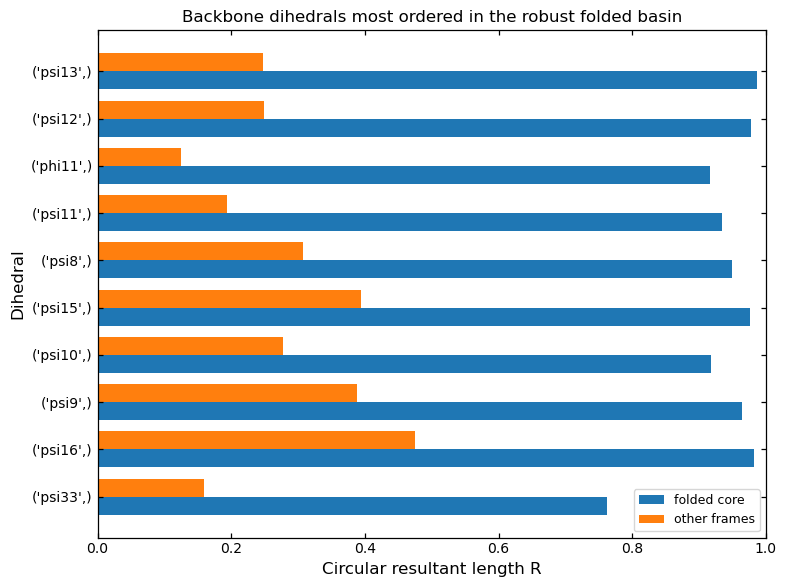

In [110]:


top_n = 10

plot_df = ranked_dihedrals.head(top_n).copy()
plot_df["label"] = plot_df["dihedral_col"].astype(str)

# If labels are readable, use them
plot_df["label"] = plot_df["dihedral_label"].astype(str)

plot_df = plot_df.iloc[::-1]

y = np.arange(len(plot_df))
height = 0.38

fig, ax = plt.subplots(figsize=(8, max(6, 0.25 * top_n)))

ax.barh(
    y - height / 2,
    plot_df["R_folded"],
    height,
    label="folded core"
)

ax.barh(
    y + height / 2,
    plot_df["R_other"],
    height,
    label="other frames"
)

ax.set_yticks(y)
ax.set_yticklabels(plot_df["label"])
ax.set_xlim(0, 1)

ax.set_xlabel("Circular resultant length R")
ax.set_ylabel("Dihedral")
ax.set_title("Backbone dihedrals most ordered in the robust folded basin")
ax.legend()

plt.tight_layout()

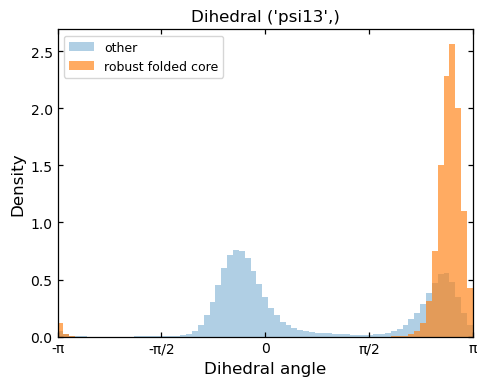

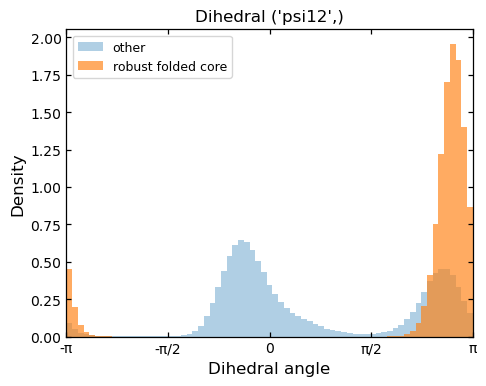

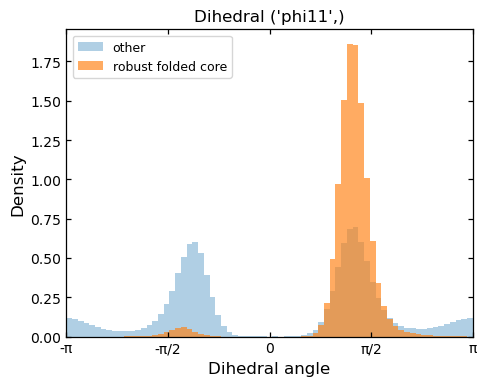

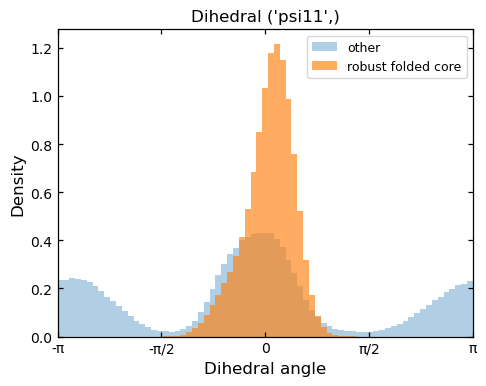

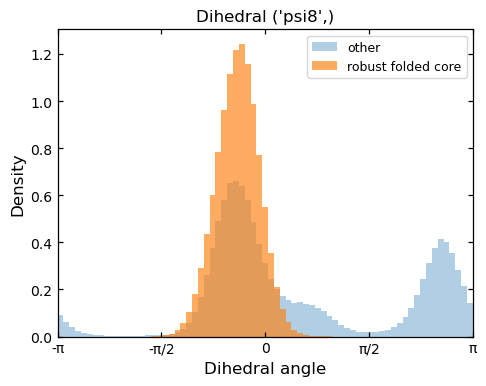

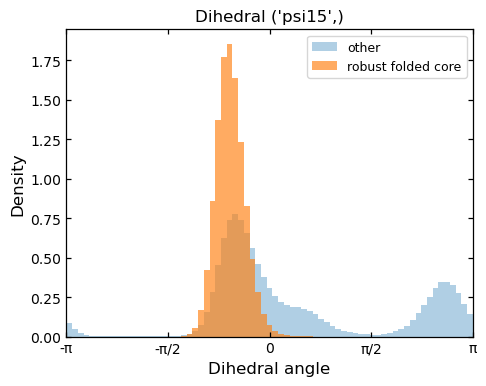

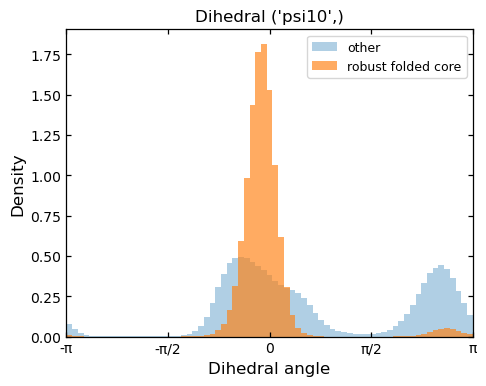

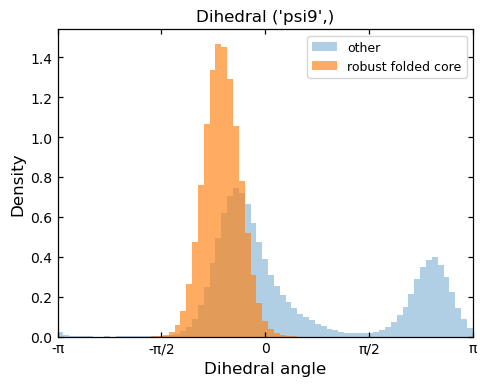

In [111]:
top_cols = ranked_dihedrals["dihedral_col"].head(8).values

bins = np.linspace(-np.pi, np.pi, 72)

for k in top_cols:
    x = dihedrals_rad[:, k]

    label = tuple(np.atleast_1d(dihedrals_index[k]))

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.hist(
        x[other_mask],
        bins=bins,
        density=True,
        alpha=0.35,
        label="other"
    )

    ax.hist(
        x[folded_mask],
        bins=bins,
        density=True,
        alpha=0.65,
        label="robust folded core"
    )

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels(["-π", "-π/2", "0", "π/2", "π"])

    ax.set_xlabel("Dihedral angle")
    ax.set_ylabel("Density")
    ax.set_title(f"Dihedral {label}")
    ax.legend()

    plt.tight_layout()

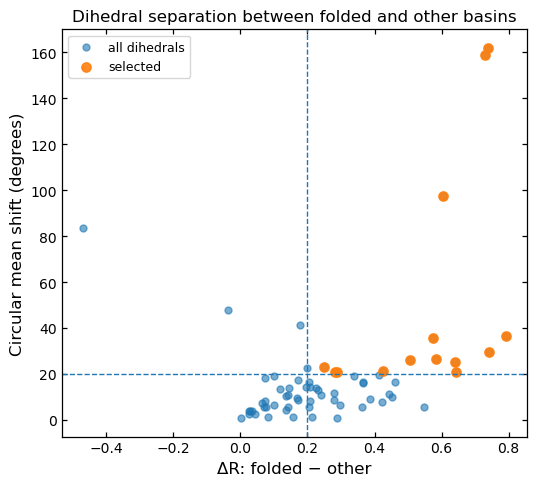

In [112]:
fig, ax = plt.subplots(figsize=(5.5, 5))

ax.scatter(
    all_dihedral_df["delta_R_folded_minus_other"],
    all_dihedral_df["mean_shift_deg"],
    s=25,
    alpha=0.6,
    label="all dihedrals"
)

ax.scatter(
    most_different_dihedrals["delta_R_folded_minus_other"],
    most_different_dihedrals["mean_shift_deg"],
    s=45,
    alpha=0.9,
    label="selected"
)

ax.axvline(0.2, linestyle="--", linewidth=1)
ax.axhline(20, linestyle="--", linewidth=1)

ax.set_xlabel("ΔR: folded − other")
ax.set_ylabel("Circular mean shift (degrees)")
ax.set_title("Dihedral separation between folded and other basins")
ax.legend()

plt.tight_layout()